In [2]:
import shap
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import joblib
import numpy as np


In [3]:
predictions = pd.read_parquet('predictions.parquet', engine='pyarrow')
predictions.head()

,id,clean_text,text,party,sentiment
0,1844361929781113331,many failure bidens administration directly tr...,@a_newsman Many failures of Bidens administrat...,democrat,negative
1,1844361929550332320,lie biden told american misinformation set exa...,@atensnut The lies Biden told Americans about ...,democrat,negative
2,1844361928925384711,someone talented fundraising team,@TheDemocrats here’s someone very talented for...,democrat,positive
3,1844361928585654516,chipper usd card working expressionless face,@LifeOfNapaul Chipper USD card isn’t working 😑,democrat,negative
4,1844361927495123076,yes n't done live interview real journalist si...,@MTGrepp Yes. She hasn't done a live interview...,democrat,positive


In [4]:
train = pd.read_parquet('train_labelled.parquet', engine='pyarrow')
train.head()

,clean_text,party,sentiment,sentiment_score
0,maga maha trumpvance2024 trump2024 magamovemen...,republican,positive,0.8479
1,favorite post kamala harris pretending like de...,democrat,positive,0.8545
2,ron desantis signed sb304 price gouging back a...,democrat,positive,0.8979
3,200 people dead hurricane 99 republican voted ...,republican,negative,-0.8662
4,wtaf coward afraid 60 minute 're incapable tel...,republican,negative,-0.9712


## Party Classifier

In [5]:
X_train, y_train = train['clean_text'], train['party']
X_test, y_test = predictions['clean_text'], predictions['party']

SAMPLE_SIZE = 10000
TOTAL_RECORDS = len(X_test)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS

_, sample_indices, _, _ = train_test_split(
    y_test.index,
    y_test,
    test_size=test_ratio,
    stratify=y_test,
    random_state=42
)

X_sample_test = X_test.loc[sample_indices]
y_sample_test = y_test.loc[sample_indices]


In [5]:
print(len(X_sample_test))
print(len(y_sample_test))

10000
10000


In [6]:
party_model = joblib.load("models/LightGBM_party_classifier.joblib")
tfidf = party_model.named_steps["tfidf"]
lgb_model = party_model.named_steps["clf"]

X_sample_test_tfidf = tfidf.transform(X_sample_test)

In [7]:
print("TF-IDF shape:", X_sample_test_tfidf.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))

TF-IDF shape: (10000, 20000)
Number of features: 20000


In [8]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_sample_test_tfidf)

In [9]:
print(type(shap_values.values), shap_values.values.shape)


<class 'scipy.sparse._csr.csr_matrix'> (10000, 20000)


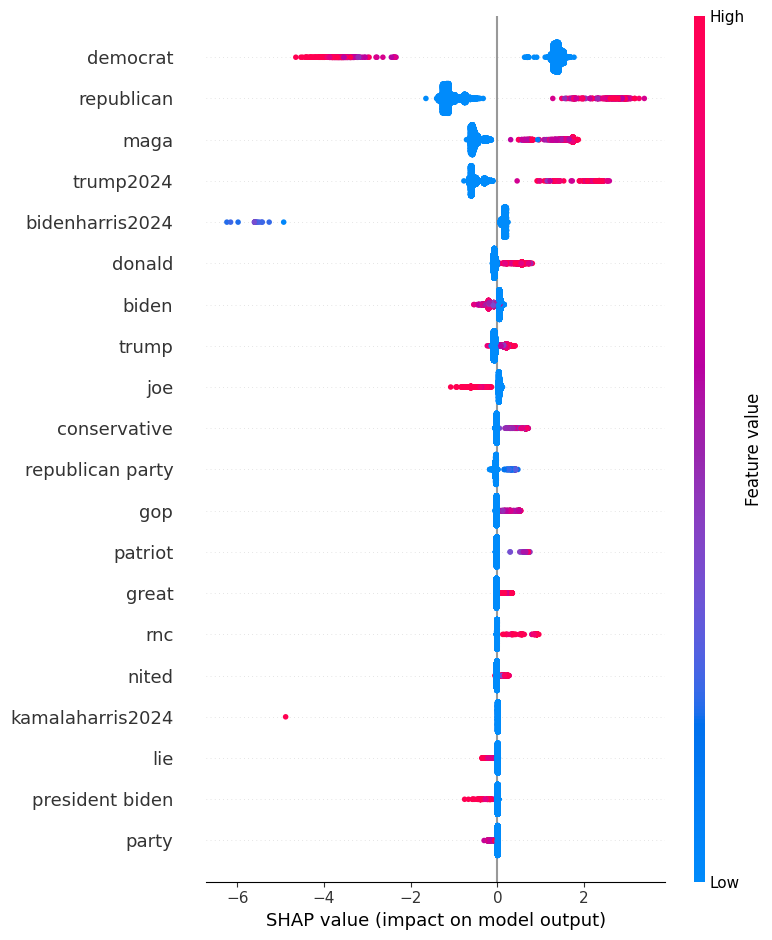

In [10]:
feature_names = tfidf.get_feature_names_out()

shap_dense = shap_values.values.toarray()  # shape: (10000, 20000)
X_dense = X_sample_test_tfidf.toarray()

shap.initjs()

shap.summary_plot(shap_dense, features=X_dense, feature_names=feature_names)


In [11]:
# shap.initjs()

# shap.plots.bar(shap.Explanation(values=shap_values[1000], 
#                                 base_values=explainer.expected_value,
#                                 feature_names=feature_names))

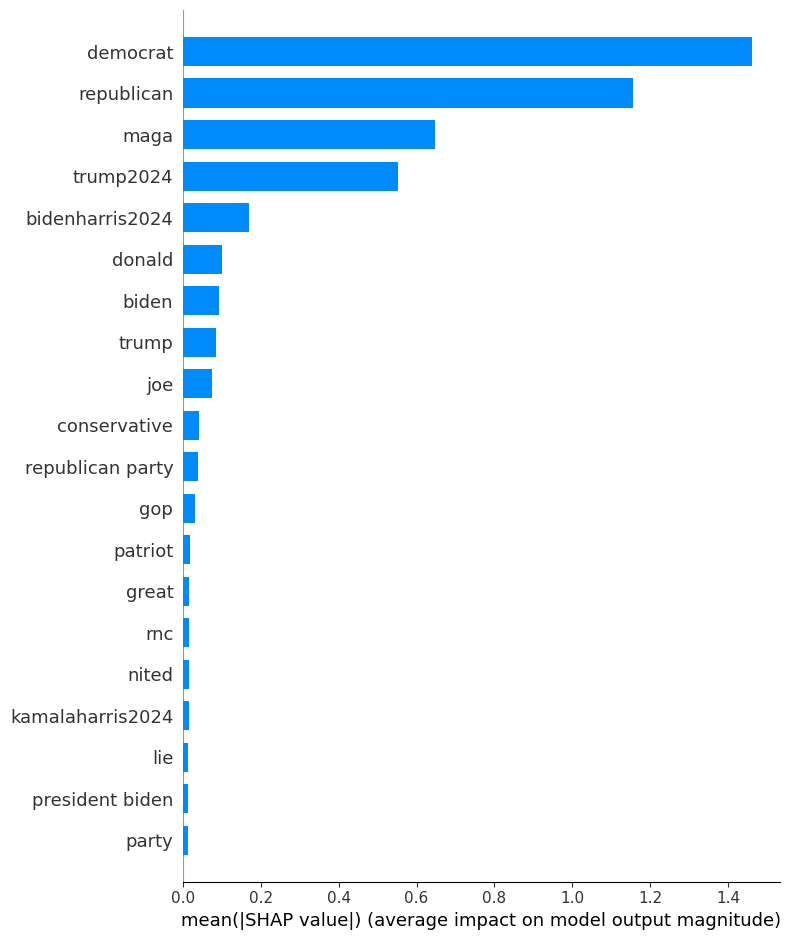

In [11]:
# Mean absolute SHAP values per feature
mean_abs_shap = np.abs(shap_dense).mean(axis=0)

# Top 50 features
top_idx = np.argsort(mean_abs_shap)[-50:]
feature_names_top = feature_names[top_idx]
shap_top = shap_dense[:, top_idx]
X_top = X_dense[:, top_idx]

# Global feature importance bar plot
shap.summary_plot(shap_top, features=X_top, feature_names=feature_names_top, plot_type="bar")


In [12]:
# Check class encoding
print("Class labels:", lgb_model.classes_)
print("Positive class (index 1):", lgb_model.classes_[1])
print("Negative class (index 0):", lgb_model.classes_[0])


Class labels: ['democrat' 'republican']
Positive class (index 1): republican
Negative class (index 0): democrat


In [13]:
# Find the "democrat" feature index
democrat_idx = np.where(feature_names == 'democrat')[0][0]
print(f"'democrat' feature index: {democrat_idx}")

'democrat' feature index: 4524


In [14]:
feature_importance = []

for i, feature_name in enumerate(feature_names):
    feature_vals = X_dense[:, i]
    shap_vals = shap_dense[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Mean_SHAP_When_Present': mean_shap_when_present,
            'Count_Present': mask.sum(),
            'Direction': 'republican' if mean_shap_when_present > 0 else 'democrat'
        })

df = pd.DataFrame(feature_importance).sort_values(
    by='Mean_SHAP_When_Present', 
    ascending=False
)


In [15]:
print("Directional Importance (top 10 pushing toward REPUBLICAN):")
df.head(10)

Directional Importance (top 10 pushing toward REPUBLICAN):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
10502,republican,2.547384,330,republican
7806,magacultmorons,2.516171,1,republican
13167,trump2024,2.083278,191,republican
7670,maga,1.548944,1160,republican
3395,democrat administration,1.534791,1,republican
3465,democrat party,1.490547,17,republican
4338,every democrat,1.435990,1,republican
13187,trump2024tosaveamerica,1.277341,3,republican
3462,democrat nominee,1.154954,1,republican
3504,democrat voter,1.119723,1,republican


In [16]:
print("Directional Importance (top 10 pushing toward DEMOCRAT):")
df.tail(10)

Directional Importance (top 10 pushing toward DEMOCRAT):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
3525,democratsareidiots,-1.134111,1,democrat
3528,democratslie,-1.210756,1,democrat
10848,rt breaking,-1.283398,6,democrat
12395,thedemocrats,-1.833544,2,democrat
3527,democratshateamerica,-1.930099,1,democrat
3526,democratscheat,-1.972371,1,democrat
1748,bidenharris2024toprotectdemocracy,-2.549722,1,democrat
3394,democrat,-3.628985,351,democrat
6812,kamalaharris2024,-4.882493,1,democrat
1746,bidenharris2024,-5.595244,18,democrat


In [39]:
# Find all original texts where "democrat party" feature is present

# 1. Find the feature index
try:
    democrat_party_idx = np.where(feature_names == 'democrat party')[0][0]
    print(f"'democrat party' feature index: {democrat_party_idx}")
except IndexError:
    print("Feature 'democrat party' not found.")
    matching = [f for f in feature_names if 'democrat' in f and 'party' in f]
    print(f"Similar features: {matching}")
    if matching:
        democrat_party_idx = np.where(feature_names == matching[0])[0][0]
        print(f"Using: '{matching[0]}' at index {democrat_party_idx}")
    else:
        raise ValueError("No matching feature found")

# 2. Get feature values and SHAP values
democrat_party_feature_vals = X_dense[:, democrat_party_idx]
democrat_party_shap_vals = shap_dense[:, democrat_party_idx]

# 3. Find samples where feature is present (non-zero)
present_mask = democrat_party_feature_vals > 0
present_indices = sample_indices[present_mask]  # Convert back to original indices

print(f"\nNumber of samples with 'democrat party': {present_mask.sum()}")

# 4. Get the original texts from predictions dataframe
results_df = predictions.loc[present_indices, ['text', 'clean_text', 'party', 'sentiment']].copy()

# 5. Add feature value and SHAP value
results_df['tfidf_value'] = democrat_party_feature_vals[present_mask]
results_df['shap_value'] = democrat_party_shap_vals[present_mask]

# 6. Sort by TF-IDF value (highest first)
results_df = results_df.sort_values('tfidf_value', ascending=False)

print(f"\nMean SHAP when present: {democrat_party_shap_vals[present_mask].mean():.6f}")
print(f"Direction: {'republican' if democrat_party_shap_vals[present_mask].mean() > 0 else 'democrat'}")

print("Text containing 'democrat party':")

for idx, row in results_df.iterrows():
    print(f"\nTF-IDF: {row['tfidf_value']:.4f} | SHAP: {row['shap_value']:.4f} | True Label: {row['party']} | Sentiment: {row['sentiment']}")
    print(f"Original: {row['text']}")
    print(f"Cleaned:  {row['clean_text']}")



'democrat party' feature index: 4762

Number of samples with 'democrat party': 17

Mean SHAP when present: 1.490547
Direction: republican

ORIGINAL TEXTS containing 'democrat_party':

TF-IDF: 0.6243 | SHAP: 1.4229 | True Label: democrat | Sentiment: positive
Original: #Biden has become the figurative Fredo of the Democrat party
Cleaned:  biden become figurative fredo democrat party
----------------------------------------------------------------------------------------------------

TF-IDF: 0.3465 | SHAP: 1.3888 | True Label: democrat | Sentiment: positive
Original: @thevivafrei Watching Kamala Harris destroy the democrat party is wonderful. God works through everyone.
Cleaned:  watching kamala harris destroy democrat party wonderful god work everyone
----------------------------------------------------------------------------------------------------

TF-IDF: 0.2511 | SHAP: 1.2204 | True Label: republican | Sentiment: positive
Original: @yalligatorgar The Republican Party is the new Dem

In [17]:
y_pred_sample = party_model.predict(X_sample_test)
misclassified_mask = y_pred_sample != y_sample_test.values

print(f"Overall Accuracy: {(~misclassified_mask).mean():.2%}")
print(f"Misclassified: {misclassified_mask.sum()} out of {len(y_pred_sample)}")


Overall Accuracy: 100.00%
Misclassified: 0 out of 10000


In [24]:
# Find instances where a single feature has SHAP > 2.0 (arbitrary threshold)
max_shap_per_instance = np.abs(shap_dense).max(axis=1)
high_leverage_mask = max_shap_per_instance > 2.0

print(f"\nInstances with single feature |SHAP| > 2.0: {high_leverage_mask.sum()} / {len(y_pred_sample)}")
print(f"Percentage: {high_leverage_mask.sum() / len(y_pred_sample) * 100:.2f}%")

# Count high-leverage predictions that are WRONG
high_leverage_and_wrong = high_leverage_mask & misclassified_mask
high_leverage_and_correct = high_leverage_mask & ~misclassified_mask

print(f"\nHigh-leverage AND correct: {high_leverage_and_correct.sum()}")
print(f"High-leverage AND wrong: {high_leverage_and_wrong.sum()}")

if high_leverage_and_wrong.sum() > 0:
    error_rate_high_leverage = high_leverage_and_wrong.sum() / high_leverage_mask.sum() * 100
    print(f"\nError rate among high-leverage: {error_rate_high_leverage:.2f}%")
else:
    print(f"\nError rate among high-leverage: 0.00%")

total_count = high_leverage_mask.sum()
if total_count < 100:
    print(f"\nCount: {total_count} - Model is robust (uses multiple features) in instances where there are single features with SHAP > 2.0")
elif total_count < 500: 
    print(f"\nCount: {total_count} - some single-feature reliance")
else:
    print(f"\nCount: {total_count} - Model can be fragile (relies on single signals in instances where there are single features with SHAP > 2.0)")

if high_leverage_and_wrong.sum() > 10:
    print(f" {high_leverage_and_wrong.sum()} high-leverage predictions are wrong")
elif high_leverage_and_wrong.sum() > 0:
    print(f"Only {high_leverage_and_wrong.sum()} high-leverage errors")
else:
    print(f"All high-leverage predictions are correct")

print(f"Instances with single feature |SHAP| > 2.0: {high_leverage_mask.sum()}")

if high_leverage_mask.sum() > 0:
    print("\nExamples of high-leverage predictions:")
    for i in np.where(high_leverage_mask)[0][:5]: 
        max_feature_idx = np.argmax(np.abs(shap_dense[i]))
        max_shap = shap_dense[i, max_feature_idx]
        feature_name = feature_names[max_feature_idx]
        true_label = y_sample_test.iloc[i]
        pred_label = y_pred_sample[i]
        
        print(f"\n  Sample {i}:")
        print(f"    Dominant feature: '{feature_name}' (SHAP: {max_shap:+.4f})")
        print(f"    True: {true_label} | Predicted: {pred_label}")
        print(f"    Text: {X_sample_test.iloc[i][:150]}...")



Instances with single feature |SHAP| > 2.0: 734 / 10000
Percentage: 7.34%

High-leverage AND correct: 734
High-leverage AND wrong: 0

Error rate among high-leverage: 0.00%

Count: 734 - Model can be fragile (relies on single signals in instances where there are single features with SHAP > 2.0)
All high-leverage predictions are correct
Instances with single feature |SHAP| > 2.0: 734

Examples of high-leverage predictions:

  Sample 6:
    Dominant feature: 'democrat' (SHAP: -4.3054)
    True: democrat | Predicted: democrat
    Text: hope donald trump elected throw whole mess democrat jail life treason...

  Sample 19:
    Dominant feature: 'democrat' (SHAP: -3.6038)
    True: democrat | Predicted: democrat
    Text: blue heart republican law order definitely fair election already planning keep democrat electing nominee president kamala harris...

  Sample 26:
    Dominant feature: 'democrat' (SHAP: -3.5433)
    True: democrat | Predicted: democrat
    Text: something wrong robert denir

In [26]:
misleading_features = []

for feature_idx in range(len(feature_names)):
    feature_vals = X_dense[:, feature_idx]
    present_mask = feature_vals > 0
    
    if present_mask.sum() < 10:  # Skip rare features
        continue
    
    shap_when_present = shap_dense[present_mask, feature_idx]
    preds_when_present = y_pred_sample[present_mask]
    true_when_present = y_sample_test.values[present_mask]
    
    # Calculate accuracy when this feature is present
    accuracy_when_present = (preds_when_present == true_when_present).mean()
    mean_shap_when_present = shap_when_present.mean()
    
    # Feature is misleading if: strong SHAP but low accuracy
    if abs(mean_shap_when_present) > 0.5 and accuracy_when_present < 0.7:
        misleading_features.append({
            'Feature': feature_names[feature_idx],
            'Mean_SHAP': mean_shap_when_present,
            'Accuracy_When_Present': accuracy_when_present,
            'Count': present_mask.sum()
        })

if len(misleading_features) > 0:
    df_misleading = pd.DataFrame(misleading_features).sort_values(
        'Accuracy_When_Present'
    )
    print(f"Features with |SHAP| > 0.5 but accuracy < 70% when present:")
    df_misleading
else:
    print(f"No highly misleading features found")
    print("No features with |SHAP| > 0.5 and accuracy < 70% when present)")


No highly misleading features found
No features with |SHAP| > 0.5 and accuracy < 70% when present)


In [27]:
top_10_idx = np.argsort(mean_abs_shap_all)[-10:]

print("Top 10 features co-occurrence matrix:")
cooccurrence = np.zeros((10, 10))

for i, idx1 in enumerate(top_10_idx):
    for j, idx2 in enumerate(top_10_idx):
        if i != j:
            both_present = (X_dense[:, idx1] > 0) & (X_dense[:, idx2] > 0)
            cooccurrence[i, j] = both_present.sum()

df_cooccur = pd.DataFrame(
    cooccurrence,
    index=[feature_names[i][:15] for i in top_10_idx],
    columns=[feature_names[i][:15] for i in top_10_idx]
)
df_cooccur

Top 10 features co-occurrence matrix:


,conservative,joe,trump,biden,donald,bidenharris2024,trump2024,maga,republican,democrat
conservative,0.0,3.0,37.0,20.0,4.0,0.0,0.0,13.0,27.0,17.0
joe,3.0,0.0,112.0,683.0,35.0,0.0,5.0,11.0,15.0,37.0
trump,37.0,112.0,0.0,861.0,808.0,2.0,54.0,280.0,109.0,86.0
biden,20.0,683.0,861.0,0.0,65.0,4.0,13.0,50.0,86.0,182.0
donald,4.0,35.0,808.0,65.0,0.0,0.0,6.0,30.0,29.0,19.0
bidenharris2024,0.0,0.0,2.0,4.0,0.0,0.0,2.0,0.0,0.0,0.0
trump2024,0.0,5.0,54.0,13.0,6.0,2.0,0.0,29.0,3.0,9.0
maga,13.0,11.0,280.0,50.0,30.0,0.0,29.0,0.0,69.0,26.0
republican,27.0,15.0,109.0,86.0,29.0,0.0,3.0,69.0,0.0,50.0
democrat,17.0,37.0,86.0,182.0,19.0,0.0,9.0,26.0,50.0,0.0


In [29]:
print(f"""Model Performance:
- Overall Accuracy: {(~misclassified_mask).mean():.2%}
- Misclassifications: {misclassified_mask.sum()} samples
- High-leverage predictions: {high_leverage_mask.sum()} samples
""")

Model Performance:
- Overall Accuracy: 100.00%
- Misclassifications: 0 samples
- High-leverage predictions: 734 samples



## Democrat Sentiment Classifier

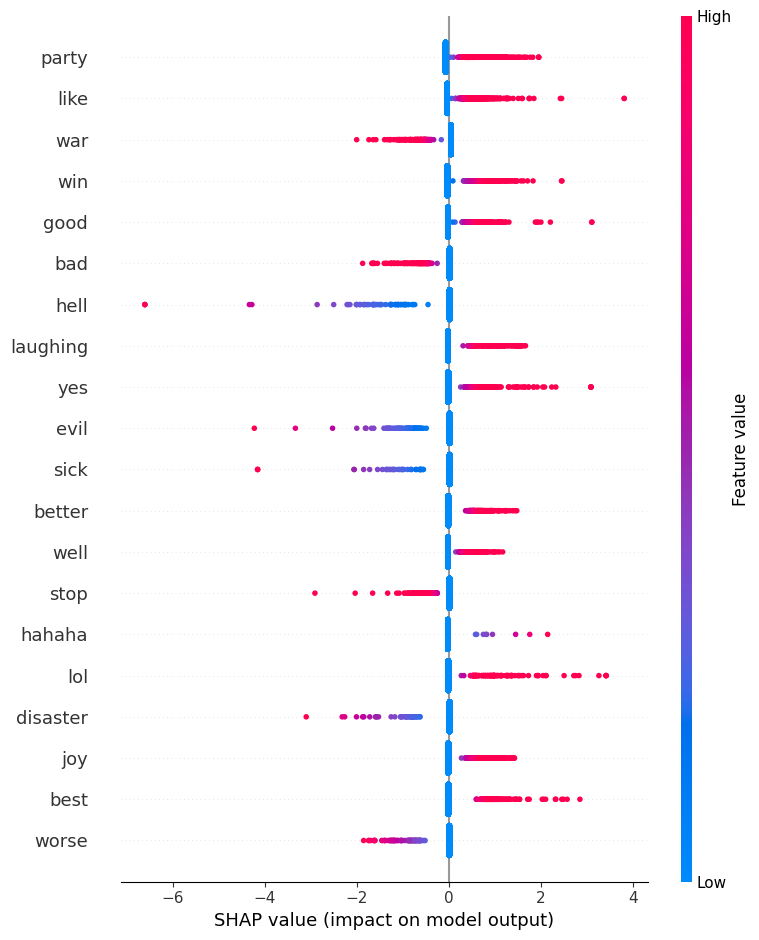

In [52]:
model = joblib.load("models/LinearSVC_democrat_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

democrat_train = train[train['party'] == 'democrat'].copy()
democrat_predict = predictions[predictions['party'] == 'democrat'].copy()

X_train, y_train = democrat_train['clean_text'], democrat_train['sentiment']
X_test, y_test = democrat_predict['clean_text'], democrat_predict['sentiment']

SAMPLE_SIZE = 10000
TOTAL_RECORDS = len(X_test)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS

_, sample_indices, _, _ = train_test_split(
    y_test.index,
    y_test,
    test_size=test_ratio,
    stratify=y_test,
    random_state=42
)

X_sample_test = X_test.loc[sample_indices]
y_sample_test = y_test.loc[sample_indices]

democrat_tfidf = tfidf.transform(X_sample_test)

democrat_tfidf_dense = democrat_tfidf.toarray()

explainer = shap.LinearExplainer(clf, democrat_tfidf_dense)
shap_values = explainer.shap_values(democrat_tfidf_dense)

dem_feature_names = tfidf.get_feature_names_out()

shap.summary_plot(
    shap_values, 
    democrat_tfidf_dense, 
    feature_names=dem_feature_names,
    title="SHAP Summary: Democratic Sentiment Classification"
)

In [45]:
class_labels = clf.classes_
print(class_labels)

['negative' 'positive']


In [ ]:
feature_importance = []

for i, feature_name in enumerate(dem_feature_names):
    feature_vals = democrat_tfidf_dense[:, i]
    shap_vals = shap_values[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Mean_SHAP_When_Present': mean_shap_when_present,
            'Count_Present': mask.sum(),
            'Direction': 'positive' if mean_shap_when_present > 0 else 'negative'
        })

dem_df = pd.DataFrame(feature_importance).sort_values(
    by='Mean_SHAP_When_Present', 
    ascending=False
)

print("Directional Importance (top 10 pushing toward positive sentiment):")
dem_df.head(10)


In [54]:
print("Directional Importance (top 10 pushing toward negative sentiment):")
dem_df.tail(10)

Directional Importance (top 10 pushing toward negative sentiment):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
5709,pissed,-1.124723,11,negative
4307,kill,-1.161003,38,negative
7168,suicide,-1.179751,7,negative
3723,hated,-1.200135,5,negative
8542,wtf,-1.297008,28,negative
8483,worst,-1.313526,63,negative
6789,sick,-1.339382,37,negative
1915,crappy,-1.481284,2,negative
1984,cruel,-1.768016,1,negative
3773,hell,-1.792476,60,negative


In [65]:
y_pred_sample = model.predict(X_sample_test)
misclassified_mask = y_pred_sample != y_sample_test.values

print(f"Overall Accuracy: {(~misclassified_mask).mean():.2%}")
print(f"Misclassified: {misclassified_mask.sum()} out of {len(y_pred_sample)}")

Overall Accuracy: 100.00%
Misclassified: 0 out of 10000


In [68]:
max_shap_per_instance = np.abs(shap_values).max(axis=1)
high_leverage_mask = max_shap_per_instance > 2.0

print(f"\nInstances with single feature |SHAP| > 2.0: {high_leverage_mask.sum()} / {len(y_pred_sample)}")
print(f"Percentage: {high_leverage_mask.sum() / len(y_pred_sample) * 100:.2f}%")

high_leverage_and_wrong = high_leverage_mask & misclassified_mask
high_leverage_and_correct = high_leverage_mask & ~misclassified_mask

print(f"\nHigh-leverage AND correct: {high_leverage_and_correct.sum()}")
print(f"High-leverage AND wrong: {high_leverage_and_wrong.sum()}")

if high_leverage_and_wrong.sum() > 0:
    error_rate_high_leverage = high_leverage_and_wrong.sum() / high_leverage_mask.sum() * 100
    print(f"Error rate among high-leverage: {error_rate_high_leverage:.2f}%")
else:
    print(f"Error rate among high-leverage: 0.00%")

if high_leverage_mask.sum() > 0:    
    if high_leverage_and_correct.sum() > 0:
        print("\nCorrect high-leverage predictions:")
        for i in np.where(high_leverage_and_correct)[0][:3]:
            max_feature_idx = np.argmax(np.abs(shap_values[i]))
            max_shap = shap_values[i, max_feature_idx]
            feature_name = dem_feature_names[max_feature_idx]  # Changed: use dem_feature_names
            true_label = y_sample_test.iloc[i]
            pred_label = y_pred_sample[i]
            
            # Get original text
            original_idx = sample_indices[i]
            original_text = democrat_predict.loc[original_idx, 'text'] if original_idx in democrat_predict.index else "N/A"
            
            print(f"\nSample {i}:")
            print(f"Dominant: '{feature_name}' (SHAP: {max_shap:+.4f})")
            print(f"True: {true_label} | Predicted: {pred_label}")
            print(f"Cleaned: {X_sample_test.iloc[i][:150]}...")
            print(f"Original: {original_text[:150]}...")
    
    # Show wrong ones if they exist
    if high_leverage_and_wrong.sum() > 0:
        print("\Wrong high-leverage predictions:")
        for i in np.where(high_leverage_and_wrong)[0][:3]:
            max_feature_idx = np.argmax(np.abs(shap_values[i]))
            max_shap = shap_values[i, max_feature_idx]
            feature_name = dem_feature_names[max_feature_idx]  # Changed: use dem_feature_names
            true_label = y_sample_test.iloc[i]
            pred_label = y_pred_sample[i]
            
            # Get original text
            original_idx = sample_indices[i]
            original_text = democrat_predict.loc[original_idx, 'text'] if original_idx in democrat_predict.index else "N/A"
            
            print(f"\nSample {i}:")
            print(f"Dominant: '{feature_name}' (SHAP: {max_shap:+.4f})")
            print(f"True: {true_label} | Predicted: {pred_label}")
            print(f"Cleaned: {X_sample_test.iloc[i][:150]}...")
            print(f"Original: {original_text[:150]}...")




Instances with single feature |SHAP| > 2.0: 245 / 10000
Percentage: 2.45%

High-leverage AND correct: 245
High-leverage AND wrong: 0
Error rate among high-leverage: 0.00%

Correct high-leverage predictions:

Sample 2:
Dominant: 'true' (SHAP: +2.3212)
True: positive | Predicted: positive
Cleaned: true...
Original: @Lynnebf_2846 @RNC Not true...

Sample 82:
Dominant: 'lie' (SHAP: -2.5583)
True: negative | Predicted: negative
Cleaned: lie...
Original: @ZaleskiLuke @elonmusk More lies...

Sample 97:
Dominant: 'dead' (SHAP: -2.1898)
True: negative | Predicted: negative
Cleaned: biden wanted dead would dead remember sjc gave permission...
Original: @HowardINo672988 If Biden wanted him dead he would be dead remember the SJC gave him permission...


## Republican Sentiment Classifier

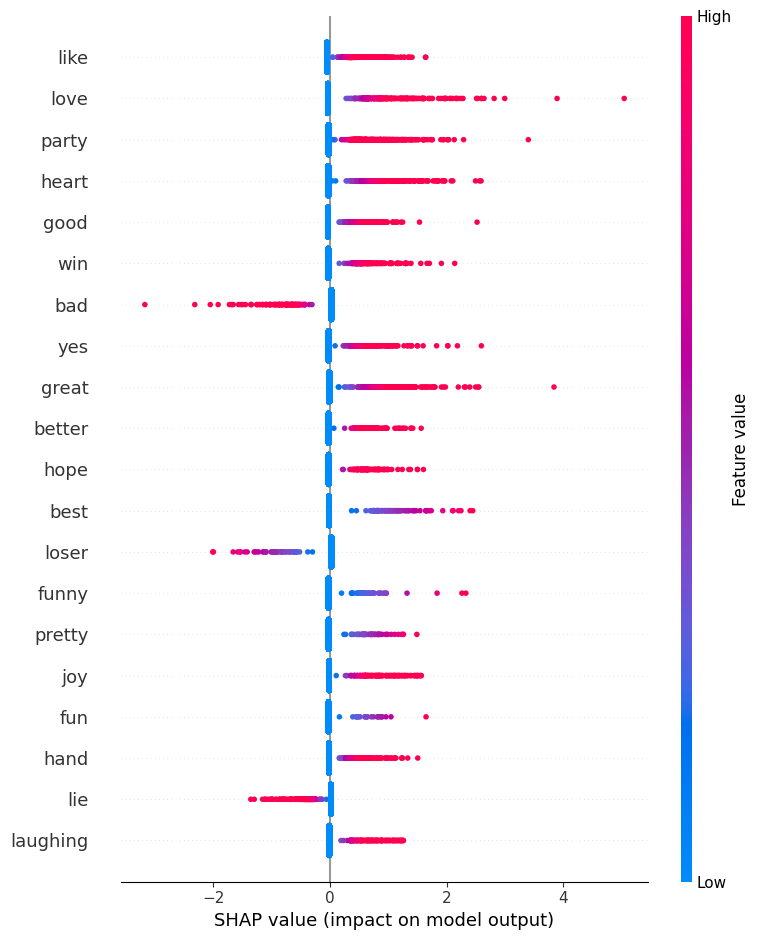

In [72]:
model = joblib.load("models/LinearSVC_republican_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

rep_train = train[train['party'] == 'republican'].copy()
rep_predict = predictions[predictions['party'] == 'republican'].copy()

X_train, y_train = rep_train['clean_text'], rep_train['sentiment']
X_test, y_test = rep_predict['clean_text'], rep_predict['sentiment']

SAMPLE_SIZE = 10000
TOTAL_RECORDS = len(X_test)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS

_, sample_indices, _, _ = train_test_split(
    y_test.index,
    y_test,
    test_size=test_ratio,
    stratify=y_test,
    random_state=42
)

X_sample_test = X_test.loc[sample_indices]
y_sample_test = y_test.loc[sample_indices]

republican_tfidf = tfidf.transform(X_sample_test)
republican_tfidf_dense = republican_tfidf.toarray()

explainer = shap.LinearExplainer(clf, republican_tfidf_dense)
shap_values = explainer.shap_values(republican_tfidf_dense)

shap.summary_plot(
    shap_values, 
    republican_tfidf_dense,
    feature_names=tfidf.get_feature_names_out(),
    title="SHAP Summary: Republican Sentiment Classification"
)

In [73]:
feature_importance = []

for i, feature_name in enumerate(dem_feature_names):
    feature_vals = republican_tfidf_dense[:, i]
    shap_vals = shap_values[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Mean_SHAP_When_Present': mean_shap_when_present,
            'Count_Present': mask.sum(),
            'Direction': 'positive' if mean_shap_when_present > 0 else 'negative'
        })

rep_df = pd.DataFrame(feature_importance).sort_values(
    by='Mean_SHAP_When_Present', 
    ascending=False
)

print("Directional Importance (top 10 pushing toward positive sentiment):")
rep_df.head(10)


Directional Importance (top 10 pushing toward positive sentiment):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
722,barely,1.688682,44,positive
627,attempt life,1.312870,26,positive
320,align,1.200426,30,positive
3232,fixed,1.167549,5,positive
661,az,1.157742,2,positive
4342,journalism,1.117963,22,positive
774,behind scene,1.109670,94,positive
5230,mr president,1.068941,3,positive
4323,job biden,1.060682,243,positive
3141,feeble,1.005828,230,positive


In [74]:
print("Directional Importance (top 10 pushing toward negative sentiment):")
rep_df.tail(10)

Directional Importance (top 10 pushing toward negative sentiment):


,Feature,Mean_SHAP_When_Present,Count_Present,Direction
6554,rnc convention,-1.172825,11,negative
2829,enemy within,-1.185338,1,negative
2022,dear,-1.189534,13,negative
8608,worst candidate,-1.198418,30,negative
6764,seek,-1.244477,31,negative
1146,blaming,-1.285666,3,negative
3407,genuine,-1.347657,51,negative
6831,sexual abuse,-1.428630,2,negative
1760,contribution,-1.433376,2,negative
2097,dementia,-1.472605,2,negative
